In [282]:
import geopandas as gpd
import joblib
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats
from sklearn import metrics
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from matplotlib_map_utils.core.scale_bar import ScaleBar, scale_bar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from matplotlib import patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


In [283]:
sns.set_context("poster",font_scale=0.8)

In [284]:
skolky_venkov = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_venkov.parquet")
skolky_venkov["kombinace"]=skolky_venkov["kombinace"]=2
skolky_mesto = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_mesto.parquet")
skolky_mesto["kombinace"]=skolky_mesto["kombinace"]=1
skolky_mesto.loc[skolky_mesto["Název_ORP"] == "Hlavní město Praha", "kombinace"] = 3

skolky_body = pd.concat(
    [skolky_venkov, skolky_mesto]
)
skolky_body=skolky_body.drop(columns=["index_right"])

In [285]:
#skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")


In [286]:
obce_polygony = gpd.read_file("geometrie/OBCE_SILC.shp").to_crs(5514)


In [288]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")
kraje_polygony = kraje_polygony.to_crs(5514)

In [289]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

In [291]:

# Define your three anchor colors
custom_colors = [
    "#003657",  # Dark Navy  (low)
        "#003657",  # Dark Navy  (low)

    "#007A87",  # Teal       (mid)
        "#007A87",  # Teal       (mid)

    "#84A98C",  # Goldenrod  (high)
    "#E6B325",  # Goldenrod  (high)
]

# Create the colormap
custom_viridis = LinearSegmentedColormap.from_list(
    "custom_viridis", custom_colors, N=256
)



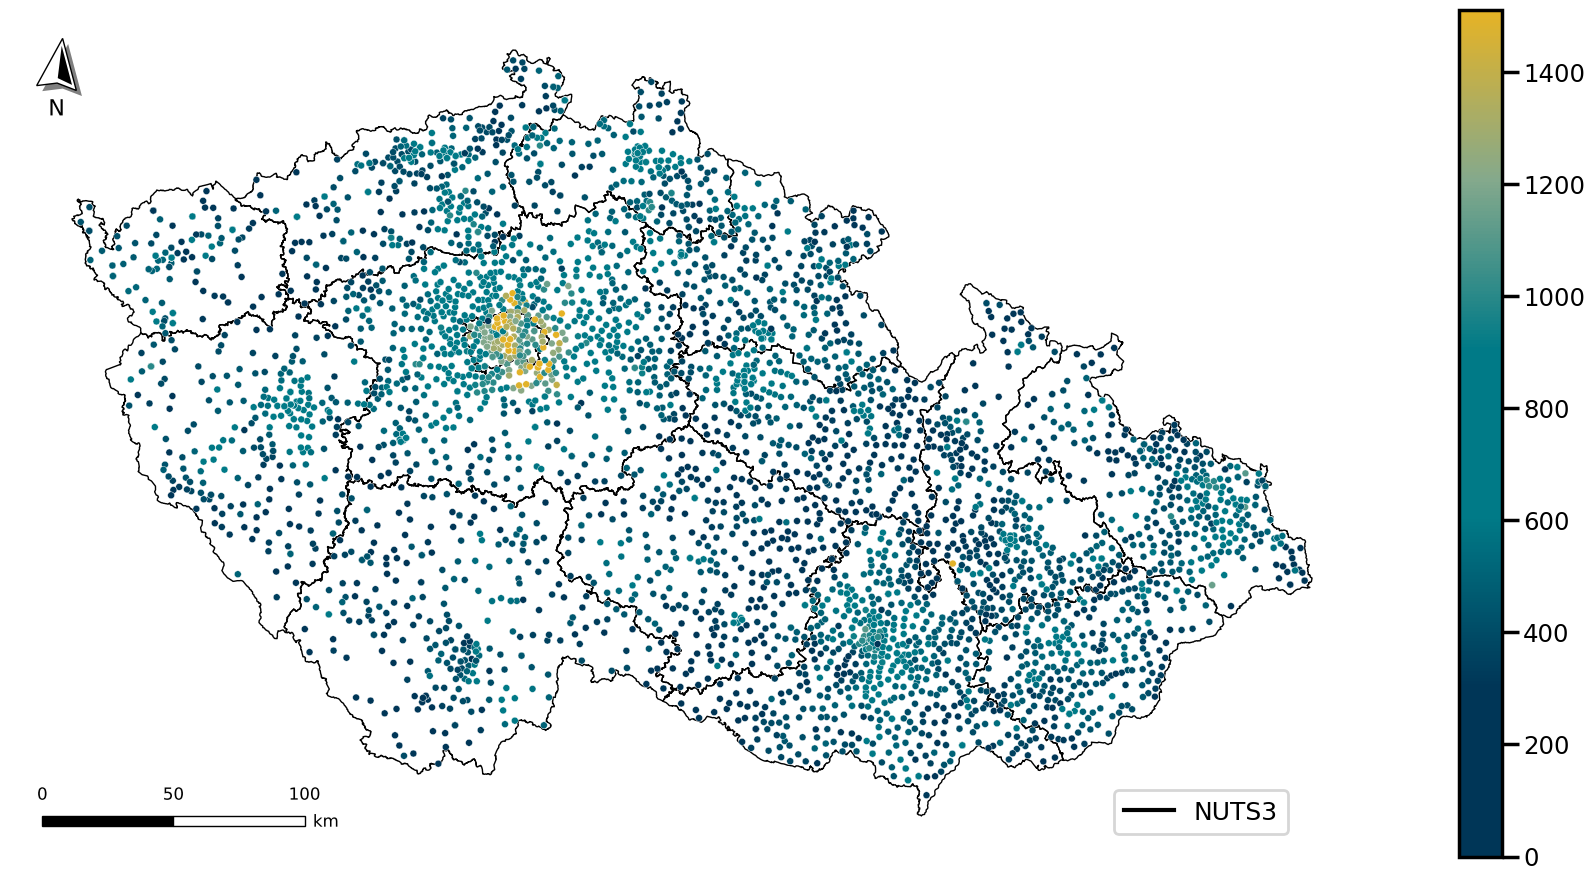

In [292]:
ax = kraje_polygony.plot(facecolor="none",   figsize=(22,11), edgecolor="black", linewidth=1)
skolky_body.plot(ax=ax, column="monthly_fe", markersize=25,legend=True,cmap=custom_viridis,edgecolors='white', linewidth=0.3)
ax.set_axis_off()

patches = []

line_patch = Line2D([0], [0], color='black', linewidth=3, label='NUTS3')
patches.append(line_patch)

ax.legend(handles=patches, 
                fontsize=18, 
                title_fontsize=28,    
                loc='center left',          
                bbox_to_anchor=(0.8, 0.05)  )

scale_bar(
    ax, location="lower left", style="boxes", bar={"projection": skolky_body.crs, "unit": "km"}
)
north_arrow(
    ax, location="upper left", rotation={"crs": skolky_body.crs, "reference": "center"}
)
plt.savefig("map.png", dpi=300, bbox_inches="tight")


In [114]:
skolky_body["monthly_fe"].notna().sum()

np.int64(4787)

In [293]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [294]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony[["geometry","count"]], how="inner")
#obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [295]:
avg_price = obce_skolky.groupby('KOD_OBEC').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['KOD_OBEC','monthly_fe']}
})


In [296]:
std_price = obce_skolky.groupby('KOD_OBEC').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['KOD_OBEC','monthly_fe']}
})


# TYP

<Axes: >

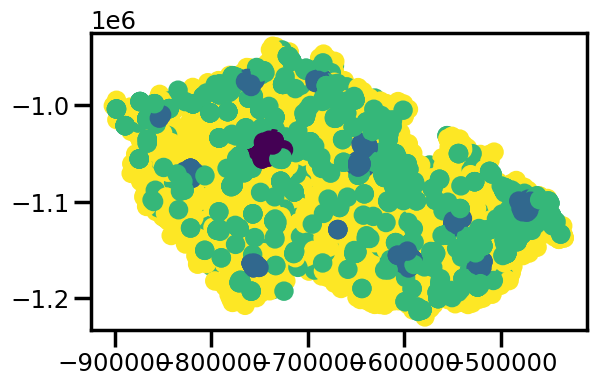

In [297]:
obce_skolky.plot("TYP_KOD")

In [298]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    columns="TYP_KOD",
    aggfunc="mean"
).round()
avg


TYP_KOD,1,2,3,4
monthly_fe,1204.0,667.0,558.0,446.0


In [299]:
avg.mean(axis=0).round()

TYP_KOD
1    1204.0
2     667.0
3     558.0
4     446.0
dtype: float64

In [300]:
std = std_price.pivot_table(
    values="monthly_fe",
    columns="TYP_KOD",
    aggfunc="mean"
).round()
std


TYP_KOD,1,2,3,4
monthly_fe,224.0,68.0,19.0,21.0


In [301]:
std.mean(axis=0).round()

TYP_KOD
1    224.0
2     68.0
3     19.0
4     21.0
dtype: float64

# OBLAST

<Axes: >

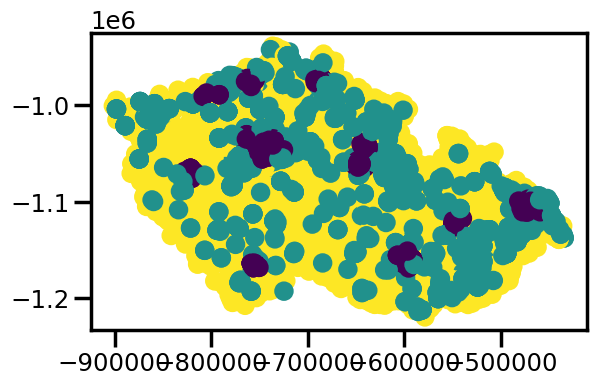

In [302]:
obce_skolky.plot("OBLAST_KOD")

In [303]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    columns="OBLAST_KOD",
    aggfunc="mean"
).round()
avg


OBLAST_KOD,1,2,3
monthly_fe,700.0,613.0,424.0


In [304]:
std = std_price.pivot_table(
    values="monthly_fe",
    columns="OBLAST_KOD",
    aggfunc="mean"
).round()
std


OBLAST_KOD,1,2,3
monthly_fe,76.0,17.0,26.0


# KRAJ

<Axes: >

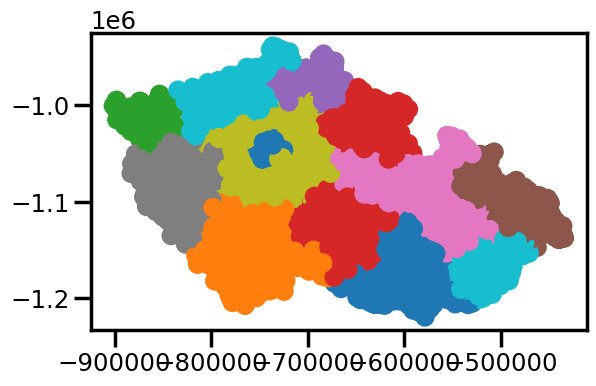

In [305]:
obce_skolky.plot("Kraj")

In [306]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    columns="Kraj",
    aggfunc="mean"
).round()
avg

Kraj,Hlavní město Praha,Jihomoravský kraj,Jihočeský kraj,Karlovarský kraj,Kraj Vysočina,Královéhradecký kraj,Liberecký kraj,Moravskoslezský kraj,Olomoucký kraj,Pardubický kraj,Plzeňský kraj,Středočeský kraj,Zlínský kraj,Ústecký kraj
monthly_fe,1204.0,445.0,375.0,412.0,348.0,431.0,480.0,429.0,365.0,391.0,444.0,660.0,428.0,446.0


In [307]:
std = std_price.pivot_table(
    values="monthly_fe",
    columns="Kraj",
    aggfunc="mean"
).round()
std

Kraj,Hlavní město Praha,Jihomoravský kraj,Jihočeský kraj,Karlovarský kraj,Kraj Vysočina,Královéhradecký kraj,Liberecký kraj,Moravskoslezský kraj,Olomoucký kraj,Pardubický kraj,Plzeňský kraj,Středočeský kraj,Zlínský kraj,Ústecký kraj
monthly_fe,224.0,15.0,4.0,25.0,20.0,32.0,43.0,21.0,31.0,21.0,6.0,12.0,20.0,30.0


# Počty


In [308]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [309]:
size_counts_total = obce_skolky.groupby("TYP_KOD").size()
size_counts = fee.groupby('TYP_KOD').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].quantile(0.75)

table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
TYP_KOD,,,,,,,
1,300,300,100.0,1204.0,1200.0,224.0,1350.0
2,435,435,100.0,733.0,700.0,174.0,889.0
3,981,981,100.0,601.0,600.0,186.0,700.0
4,3071,3071,100.0,446.0,406.0,195.0,502.0


In [310]:
size_counts_total = obce_skolky.groupby("OBLAST_KOD").size()
size_counts = fee.groupby('OBLAST_KOD').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].quantile(0.75)


table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
OBLAST_KOD,,,,,,,
1,759,759,100.0,923.0,900.0,298.0,1140.0
2,1206,1206,100.0,614.0,600.0,221.0,711.0
3,2822,2822,100.0,425.0,400.0,165.0,500.0


In [311]:
size_counts_total = obce_skolky.groupby("Kraj").size()
size_counts = fee.groupby('Kraj').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('Kraj')['monthly_fe'].quantile(0.75)


table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
Kraj,,,,,,,
Hlavní město Praha,299,299,100.0,1205.0,1200.0,223.0,1350.0
Jihomoravský kraj,628,628,100.0,549.0,500.0,224.0,700.0
Jihočeský kraj,300,300,100.0,386.0,400.0,111.0,450.0
Karlovarský kraj,117,117,100.0,460.0,466.0,151.0,600.0
Kraj Vysočina,281,281,100.0,374.0,343.0,155.0,446.0
Královéhradecký kraj,289,289,100.0,460.0,432.0,128.0,562.0
Liberecký kraj,212,212,100.0,582.0,528.0,196.0,742.0
Moravskoslezský kraj,406,406,100.0,505.0,500.0,208.0,600.0
Olomoucký kraj,349,349,100.0,417.0,400.0,181.0,506.0


# Kombinace

In [312]:
#obce_skolky["kraj_oblast_typ"] = obce_skolky["Kraj"].astype("str") + obce_skolky["OBLAST_KOD"].astype("str") + obce_skolky["TYP_KOD"].astype("str")

In [124]:
obce_skolky["kraj_oblast_typ"] = obce_skolky["Kraj"].astype("str") + obce_skolky["kombinace"].astype("str")

In [125]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [126]:
df = obce_skolky

In [315]:


# 1. Configuration (Same as before)
combination_colors = {
    "11": "#D22D40", # Metropole (Praha) -> Crimson
    "12": "#003657", # Krajská města -> Navy
    "13": "#4A5D23", # Hustě obydlená -> Teal Blue
    "22": "#84A98C", # Městské obce -> Sage Green
    "23": "#E6B325", # Středně obydlená -> Goldenrod
    "24": "#B85C38", # Středně obydlená -> Goldenrod
    "33": "#708090", # Venkovské obce -> Slate Gray
    "34": "#007A87", # Venkovské obce -> Slate Gray #007A87
     "2": "#007A87", # Venkovské obce -> Slate Gray #007A87
    "1": "#E6B325",
    "3": "#D22D40", # Středně obydlená -> Goldenrod
}

combination_names = {
    "11": "11: Metropole (Praha)", "12": "12: Krajská města (Hustě)", "13": "13: Hustě obydlená",
    "22": "22: Městské obce (Středně)", "23": "23: Středně obydlená", "24": "24: Středně obydlená (Venkov)",
    "33": "33: Venkovské obce (Městské)", "34": "34: Venkovské obce",   "3":"Capital City of Prague", "1": "Urban Areas",
    "2": "Rural areas", 
}

def get_combo_color(label):
    digits = "".join(filter(str.isdigit, label))[-2:]
    return combination_colors.get(digits, "#000000")

def get_region_base(label):
    return "".join([i for i in label if not i.isdigit()]).strip()

# --- NEW SORTING LOGIC ---
# First, ensure we have a 'region_only' column to calculate the mean
df['region_only'] = df['kraj_oblast_typ'].apply(get_region_base)

# Calculate the mean monthly fee per region
region_means = df.groupby('region_only')['monthly_fe'].mean().reset_index()
region_means.columns = ['region_only', 'region_mean']

# Merge the means back into the main dataframe
df_ = df.merge(region_means, on='region_only')

# Sort by the Mean (highest first), then by the full string (to keep 11, 12, 13 together)
df_sorted = df_.sort_values(by=['region_mean', 'kraj_oblast_typ'], ascending=[False, True])

# --- PREPARE PLOT DATA ---
groups = [group['monthly_fe'].values for name, group in df_sorted.groupby('kraj_oblast_typ', sort=False)]
labels = [name for name, group in df_sorted.groupby('kraj_oblast_typ', sort=False)]

jitter = 0.06
x_data = [np.array([i] * len(g)) for i, g in enumerate(groups)]
x_jittered = [x + stats.t(df=6, scale=jitter).rvs(len(x)) for x in x_data]

In [129]:
size_counts_total = obce_skolky.groupby("kraj_oblast_typ").size()
size_counts = fee.groupby('kraj_oblast_typ').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].std()
table['Q4'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].quantile(0.75)


table

,total_count,count,percentage,average_fee,median_fee,std_fee,Q4
kraj_oblast_typ,,,,,,,
Hlavní město Praha3,299,299,100.0,1205.288889,1200.000000,223.019610,1350.000000
Jihomoravský kraj1,201,201,100.0,791.254573,800.000000,179.715348,950.000000
Jihomoravský kraj2,427,427,100.0,434.542501,422.265743,133.820418,507.126865
Jihočeský kraj1,79,79,100.0,428.802177,430.000000,54.029115,450.000000
Jihočeský kraj2,221,221,100.0,370.587459,356.823574,122.105845,430.587028
Karlovarský kraj1,41,41,100.0,580.078267,600.000000,121.298643,700.000000
Karlovarský kraj2,76,76,100.0,394.543865,400.000000,122.823147,491.158386
Kraj Vysočina1,30,30,100.0,675.651048,700.000000,135.899714,799.826010
Kraj Vysočina2,251,251,100.0,337.879312,329.709407,111.986128,400.000000


In [292]:
table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q4
kraj_oblast_typ,,,,,,,
Hlavní město Praha3,299,299,100.0,1205.0,1200.0,223.0,1350.0
Jihomoravský kraj1,201,201,100.0,791.0,800.0,180.0,950.0
Jihomoravský kraj2,427,427,100.0,435.0,422.0,134.0,507.0
Jihočeský kraj1,79,79,100.0,429.0,430.0,54.0,450.0
Jihočeský kraj2,221,221,100.0,371.0,357.0,122.0,431.0
Karlovarský kraj1,41,41,100.0,580.0,600.0,121.0,700.0
Karlovarský kraj2,76,76,100.0,395.0,400.0,123.0,491.0
Kraj Vysočina1,30,30,100.0,676.0,700.0,136.0,800.0
Kraj Vysočina2,251,251,100.0,338.0,330.0,112.0,400.0


In [132]:
median_prijem = [
    27720, 36119, 30037, 23618, 29391,
    33991, 28198, 31384, 32003, 22023,
    27172, 33446, 27499, 28764, 27373,
    33163, 23862, 26057, 27544, 26243,
    34490, 26237, 28126, 26306, 25878,
    22987, 26522
]
kindergarten_pct_income = [
    3.75, 1.70, 1.08, 1.40, 0.93,
    1.36, 1.09, 1.72, 0.79, 2.10,
    1.13, 1.77, 1.23, 1.60, 1.12,
    1.39, 1.22, 1.77, 0.98, 2.05,
    0.91, 2.31, 1.64, 1.75, 1.19,
    2.01, 1.16
]


table['median_prijem'] = median_prijem
table['kindergarten_pct_income'] = kindergarten_pct_income


In [133]:
table

,total_count,count,percentage,average_fee,median_fee,std_fee,Q4,median_prijem,kindergarten_pct_income
kraj_oblast_typ,,,,,,,,,
Hlavní město Praha3,299,299,100.0,1205.288889,1200.000000,223.019610,1350.000000,27720,3.75
Jihomoravský kraj1,201,201,100.0,791.254573,800.000000,179.715348,950.000000,36119,1.70
Jihomoravský kraj2,427,427,100.0,434.542501,422.265743,133.820418,507.126865,30037,1.08
Jihočeský kraj1,79,79,100.0,428.802177,430.000000,54.029115,450.000000,23618,1.40
Jihočeský kraj2,221,221,100.0,370.587459,356.823574,122.105845,430.587028,29391,0.93
Karlovarský kraj1,41,41,100.0,580.078267,600.000000,121.298643,700.000000,33991,1.36
Karlovarský kraj2,76,76,100.0,394.543865,400.000000,122.823147,491.158386,28198,1.09
Kraj Vysočina1,30,30,100.0,675.651048,700.000000,135.899714,799.826010,31384,1.72
Kraj Vysočina2,251,251,100.0,337.879312,329.709407,111.986128,400.000000,32003,0.79


In [134]:
obce = obce_skolky.merge(table, left_on ="kraj_oblast_typ", how="outer", right_index=True)

In [135]:
k = obce_polygony.merge(
    obce.drop(columns="geometry"),
    on="KOD_OBEC",
    how="outer"
)
k= k.drop_duplicates("geometry")

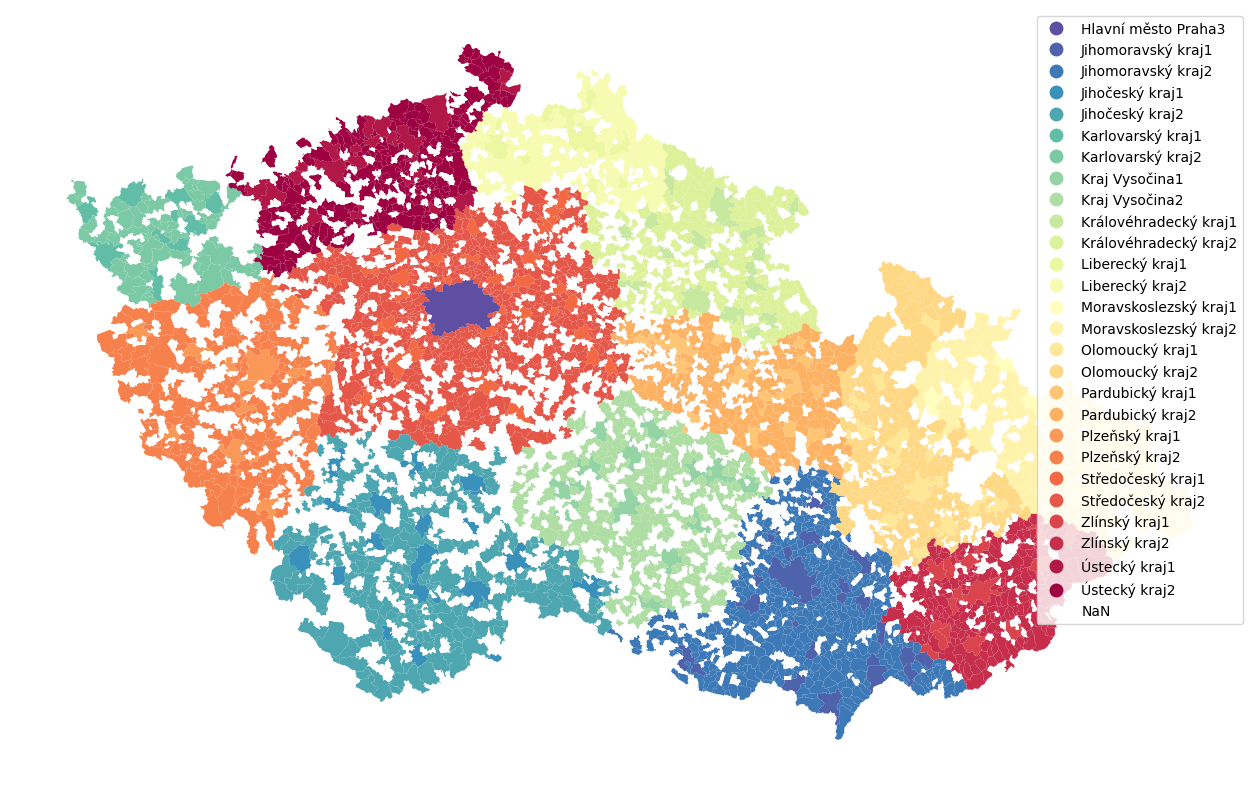

In [299]:
k.plot("kraj_oblast_typ", figsize=(16,10),legend=True,cmap="Spectral_r",missing_kwds={"color": "white"},
).set_axis_off()

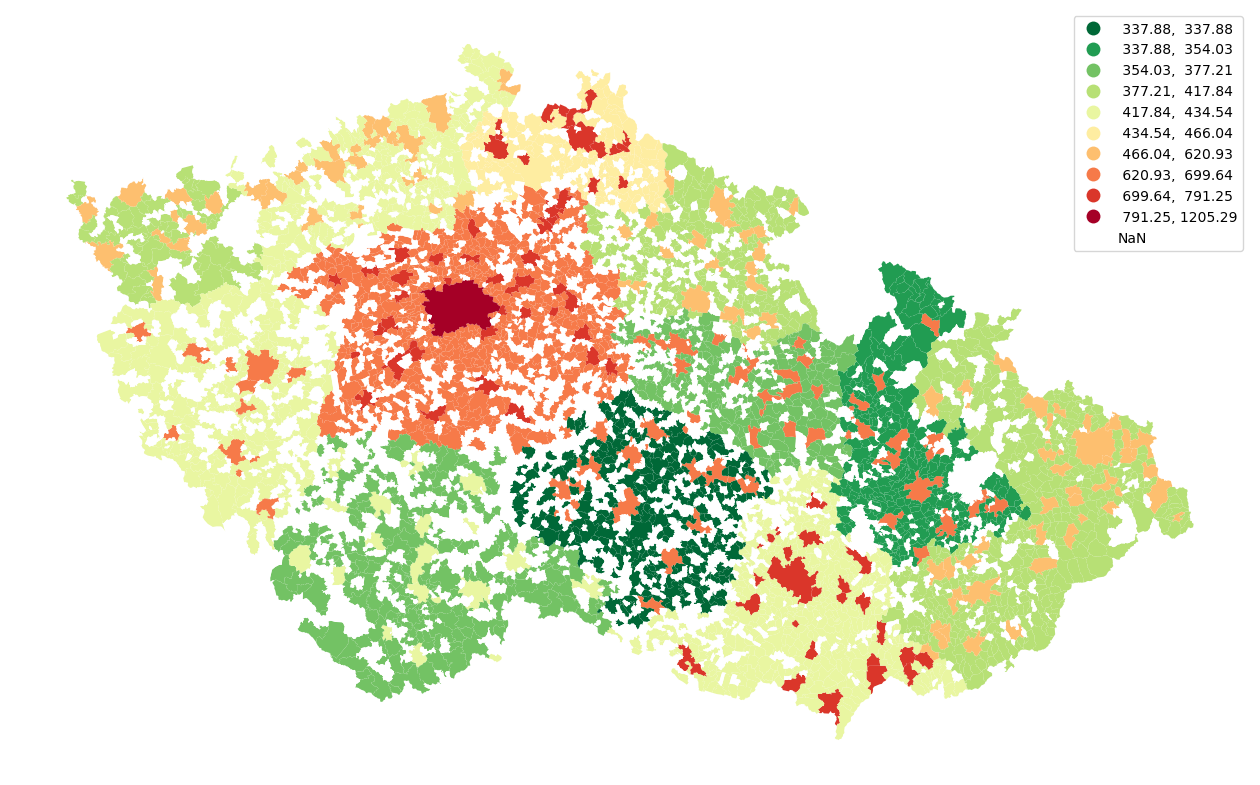

In [300]:
k.plot(
    column="average_fee",
    figsize=(16,10),
    legend=True,
    cmap="RdYlGn_r",
    missing_kwds={"color": "white"},
    scheme="natural_breaks",
    k=10
).set_axis_off()

In [136]:
mestske = table[(table.index.str.endswith('1'))| (table.index.str.endswith('3'))]
venkovske = table[table.index.str.endswith('2')]

In [150]:
mestske["median_prijem"] = [30756, 27237, 25050, 28045, 24576, 25853, 25316, 25325, 26652, 25960, 27661, 24794, 25382, 25300]
mestske["decil_prijem"]= [17596, 16673, 16620, 17686, 14725, 16409, 16204, 16452, 16903, 16115, 16642, 14892, 17386, 15611]
venkovske["median_prijem"] = [27237, 25050, 28045, 24576, 25853, 25316, 25325, 26652, 25960, 27661, 24794, 25382, 25300]
venkovske["decil_prijem"]= [16673, 16620, 17686, 14725, 16409, 16204, 16452, 16903, 16115, 16642, 14892, 17386, 15611]


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_91369/80672735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mestske["median_prijem"] = [30756, 27237, 25050, 28045, 24576, 25853, 25316, 25325, 26652, 25960, 27661, 24794, 25382, 25300]
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_91369/80672735.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mestske["decil_prijem"]= [17596, 16673, 16620, 17686, 14725, 16409, 16204, 16452, 16903, 16115, 16642, 14892, 17386, 15611]
/var/folde

In [193]:
mestske["podil_median_m"] = (mestske["median_fee"]/mestske["median_prijem"]*1.3*100).round(2)
mestske["podil_decil_m"] = (mestske["median_fee"]/mestske["decil_prijem"]*1.3*100).round(2)

/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_91369/1281289135.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mestske["podil_median_m"] = (mestske["median_fee"]/mestske["median_prijem"]*1.3*100).round(2)
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_91369/1281289135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mestske["podil_decil_m"] = (mestske["median_fee"]/mestske["decil_prijem"]*1.3*100).round(2)


In [194]:
venkovske["podil_median_v"] = (venkovske["median_fee"]/venkovske["median_prijem"]*1.3*100).round(2)
venkovske["podil_decil_v"] = (venkovske["median_fee"]/venkovske["decil_prijem"]*1.3*100).round(2)

/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_91369/2579988993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  venkovske["podil_median_v"] = (venkovske["median_fee"]/venkovske["median_prijem"]*1.3*100).round(2)
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_91369/2579988993.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  venkovske["podil_decil_v"] = (venkovske["median_fee"]/venkovske["decil_prijem"]*1.3*100).round(2)


In [268]:
mestske.iloc[1:14]["median_fee"]

kraj_oblast_typ
Jihomoravský kraj       800.000000
Jihočeský kraj          430.000000
Karlovarský kraj        600.000000
Kraj Vysočina           700.000000
Královéhradecký kraj    600.000000
Liberecký kraj          769.509982
Moravskoslezský kraj    600.000000
Olomoucký kraj          600.000000
Pardubický kraj         600.000000
Plzeňský kraj           700.000000
Středočeský kraj        787.165453
Zlínský kraj            600.000000
Ústecký kraj            600.000000
Name: median_fee, dtype: float64

In [195]:
mestske.index = mestske.index.str.rstrip('123')
venkovske.index = venkovske.index.str.rstrip('123')

In [196]:
mestske

,total_count,count,percentage,average_fee,median_fee,std_fee,Q4,median_prijem,kindergarten_pct_income,podil_median,decil_prijem,podil_decil,podil_median_m,podil_decil_m
kraj_oblast_typ,,,,,,,,,,,,,,
Hlavní město Praha,299,299,100.0,1205.288889,1200.000000,223.019610,1350.000000,30756,3.75,5.07,17596,8.87,5.07,8.87
Jihomoravský kraj,201,201,100.0,791.254573,800.000000,179.715348,950.000000,27237,1.70,3.82,16673,6.24,3.82,6.24
Jihočeský kraj,79,79,100.0,428.802177,430.000000,54.029115,450.000000,25050,1.40,2.23,16620,3.36,2.23,3.36
Karlovarský kraj,41,41,100.0,580.078267,600.000000,121.298643,700.000000,28045,1.36,2.78,17686,4.41,2.78,4.41
Kraj Vysočina,30,30,100.0,675.651048,700.000000,135.899714,799.826010,24576,1.72,3.70,14725,6.18,3.70,6.18
Královéhradecký kraj,71,71,100.0,594.014986,600.000000,112.838931,661.144026,25853,2.10,3.02,16409,4.75,3.02,4.75
Liberecký kraj,82,82,100.0,766.355826,769.509982,149.920366,871.143952,25316,1.77,3.95,16204,6.17,3.95,6.17
Moravskoslezský kraj,185,185,100.0,620.934778,600.000000,187.840475,750.000000,25325,1.60,3.08,16452,4.74,3.08,4.74
Olomoucký kraj,75,75,100.0,647.302672,600.000000,110.475769,678.977143,26652,1.39,2.93,16903,4.61,2.93,4.61


In [197]:
porovnani_m = mestske[["podil_median_m"]].transpose()
porovnani_mm = mestske[["podil_decil_m"]].transpose()

In [198]:
porovnani_v = venkovske[["podil_median_v"]].transpose()
porovnani_vv = venkovske[["podil_decil_v"]].transpose()

In [218]:
d = d.rename(columns={
    "Hlavní město Praha": "Prague",
    "Středočeský kraj": "Central Bohemian Region",
    "Jihočeský kraj": "South Bohemian Region",
    "Plzeňský kraj": "Plzeň Region",
    "Karlovarský kraj": "Karlovy Vary Region",
    "Ústecký kraj": "Ústí nad Labem Region",
    "Liberecký kraj": "Liberec Region",
    "Královéhradecký kraj": "Hradec Králové Region",
    "Pardubický kraj": "Pardubice Region",
    "Kraj Vysočina": "Vysočina Region",
    "Jihomoravský kraj": "South Moravian Region",
    "Olomoucký kraj": "Olomouc Region",
    "Zlínský kraj": "Zlín Region",
    "Moravskoslezský kraj": "Moravian-Silesian Region",
})


In [233]:
m = pd.concat([porovnani_m,porovnani_v])
m = m.rename(columns={
    "Hlavní město Praha": "Prague",
    "Středočeský kraj": "Central Bohemian Region",
    "Jihočeský kraj": "South Bohemian Region",
    "Plzeňský kraj": "Plzeň Region",
    "Karlovarský kraj": "Karlovy Vary Region",
    "Ústecký kraj": "Ústí nad Labem Region",
    "Liberecký kraj": "Liberec Region",
    "Královéhradecký kraj": "Hradec Králové Region",
    "Pardubický kraj": "Pardubice Region",
    "Kraj Vysočina": "Vysočina Region",
    "Jihomoravský kraj": "South Moravian Region",
    "Olomoucký kraj": "Olomouc Region",
    "Zlínský kraj": "Zlín Region",
    "Moravskoslezský kraj": "Moravian-Silesian Region",
})
m

kraj_oblast_typ,Prague,South Moravian Region,South Bohemian Region,Karlovy Vary Region,Vysočina Region,Hradec Králové Region,Liberec Region,Moravian-Silesian Region,Olomouc Region,Pardubice Region,Plzeň Region,Central Bohemian Region,Zlín Region,Ústí nad Labem Region
podil_median_m,5.07,3.82,2.23,2.78,3.70,3.02,3.95,3.08,2.93,3.00,3.29,4.13,3.07,3.08
podil_median_v,NaN,2.02,1.85,1.85,1.74,2.01,2.26,2.05,1.85,1.75,1.92,3.15,2.05,2.06


In [244]:
m_sorted = m.sort_values(by=m.index[0], axis=1, ascending=False)
m_sorted

kraj_oblast_typ,Prague,Central Bohemian Region,Liberec Region,South Moravian Region,Vysočina Region,Plzeň Region,Moravian-Silesian Region,Ústí nad Labem Region,Zlín Region,Hradec Králové Region,Pardubice Region,Olomouc Region,Karlovy Vary Region,South Bohemian Region
podil_median_m,5.07,4.13,3.95,3.82,3.70,3.29,3.08,3.08,3.07,3.02,3.00,2.93,2.78,2.23
podil_median_v,NaN,3.15,2.26,2.02,1.74,1.92,2.05,2.06,2.05,2.01,1.75,1.85,1.85,1.85


In [246]:
m_sorted = d.sort_values(by=d.index[1], axis=1, ascending=False)
m_sorted

kraj_oblast_typ,Central Bohemian Region,Liberec Region,Ústí nad Labem Region,South Moravian Region,Plzeň Region,Hradec Králové Region,Moravian-Silesian Region,Zlín Region,Karlovy Vary Region,Olomouc Region,Vysočina Region,Pardubice Region,South Bohemian Region,Prague
podil_decil_m,6.87,6.17,5.00,6.24,5.47,4.75,4.74,4.49,4.41,4.61,6.18,4.84,3.36,8.87
podil_decil_v,5.24,3.53,3.33,3.29,3.19,3.17,3.16,2.99,2.94,2.92,2.91,2.82,2.79,NaN


In [240]:
# Sorts columns based on the values in the very first row
m_sorted = d.sort_values(by=d.index[0], axis=1, ascending=False)

In [241]:
m_sorted

kraj_oblast_typ,Prague,Central Bohemian Region,South Moravian Region,Vysočina Region,Liberec Region,Plzeň Region,Ústí nad Labem Region,Pardubice Region,Hradec Králové Region,Moravian-Silesian Region,Olomouc Region,Zlín Region,Karlovy Vary Region,South Bohemian Region
podil_decil_m,8.87,6.87,6.24,6.18,6.17,5.47,5.00,4.84,4.75,4.74,4.61,4.49,4.41,3.36
podil_decil_v,NaN,5.24,3.29,2.91,3.53,3.19,3.33,2.82,3.17,3.16,2.92,2.99,2.94,2.79


In [206]:
m.mean(axis=1)

podil_median_m    3.367857
podil_median_v    2.043077
dtype: float64

In [221]:
d =pd.concat([porovnani_mm,porovnani_vv])
d = d.rename(columns={
    "Hlavní město Praha": "Prague",
    "Středočeský kraj": "Central Bohemian Region",
    "Jihočeský kraj": "South Bohemian Region",
    "Plzeňský kraj": "Plzeň Region",
    "Karlovarský kraj": "Karlovy Vary Region",
    "Ústecký kraj": "Ústí nad Labem Region",
    "Liberecký kraj": "Liberec Region",
    "Královéhradecký kraj": "Hradec Králové Region",
    "Pardubický kraj": "Pardubice Region",
    "Kraj Vysočina": "Vysočina Region",
    "Jihomoravský kraj": "South Moravian Region",
    "Olomoucký kraj": "Olomouc Region",
    "Zlínský kraj": "Zlín Region",
    "Moravskoslezský kraj": "Moravian-Silesian Region",
})
d.style.background_gradient(axis=1)

kraj_oblast_typ,Prague,South Moravian Region,South Bohemian Region,Karlovy Vary Region,Vysočina Region,Hradec Králové Region,Liberec Region,Moravian-Silesian Region,Olomouc Region,Pardubice Region,Plzeň Region,Central Bohemian Region,Zlín Region,Ústí nad Labem Region
podil_decil_m,8.870000,6.240000,3.360000,4.410000,6.180000,4.750000,6.170000,4.740000,4.610000,4.840000,5.470000,6.870000,4.490000,5.000000
podil_decil_v,nan,3.290000,2.790000,2.940000,2.910000,3.170000,3.530000,3.160000,2.920000,2.820000,3.190000,5.240000,2.990000,3.330000


In [229]:
# Sorting by 'podil_median_m' in descending order (highest first)
df_sorted = m.sort_values(by='podil_median_m', ascending=False)



KeyError: 'podil_median_m'

In [208]:
d.mean(axis=1)

podil_decil_m    5.428571
podil_decil_v    3.252308
dtype: float64

In [175]:
print(mestske["podil_median"].mean())
print(mestske["podil_decil"].mean())

3.367857142857143
5.428571428571429


In [155]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")
kraje_polygony = kraje_polygony.to_crs(5514)

In [156]:
kraj_m = kraje_polygony.merge(mestske, left_on ="NAZEV", right_index=True)
kraj_v = kraje_polygony.merge(venkovske, left_on ="NAZEV", right_index=True)


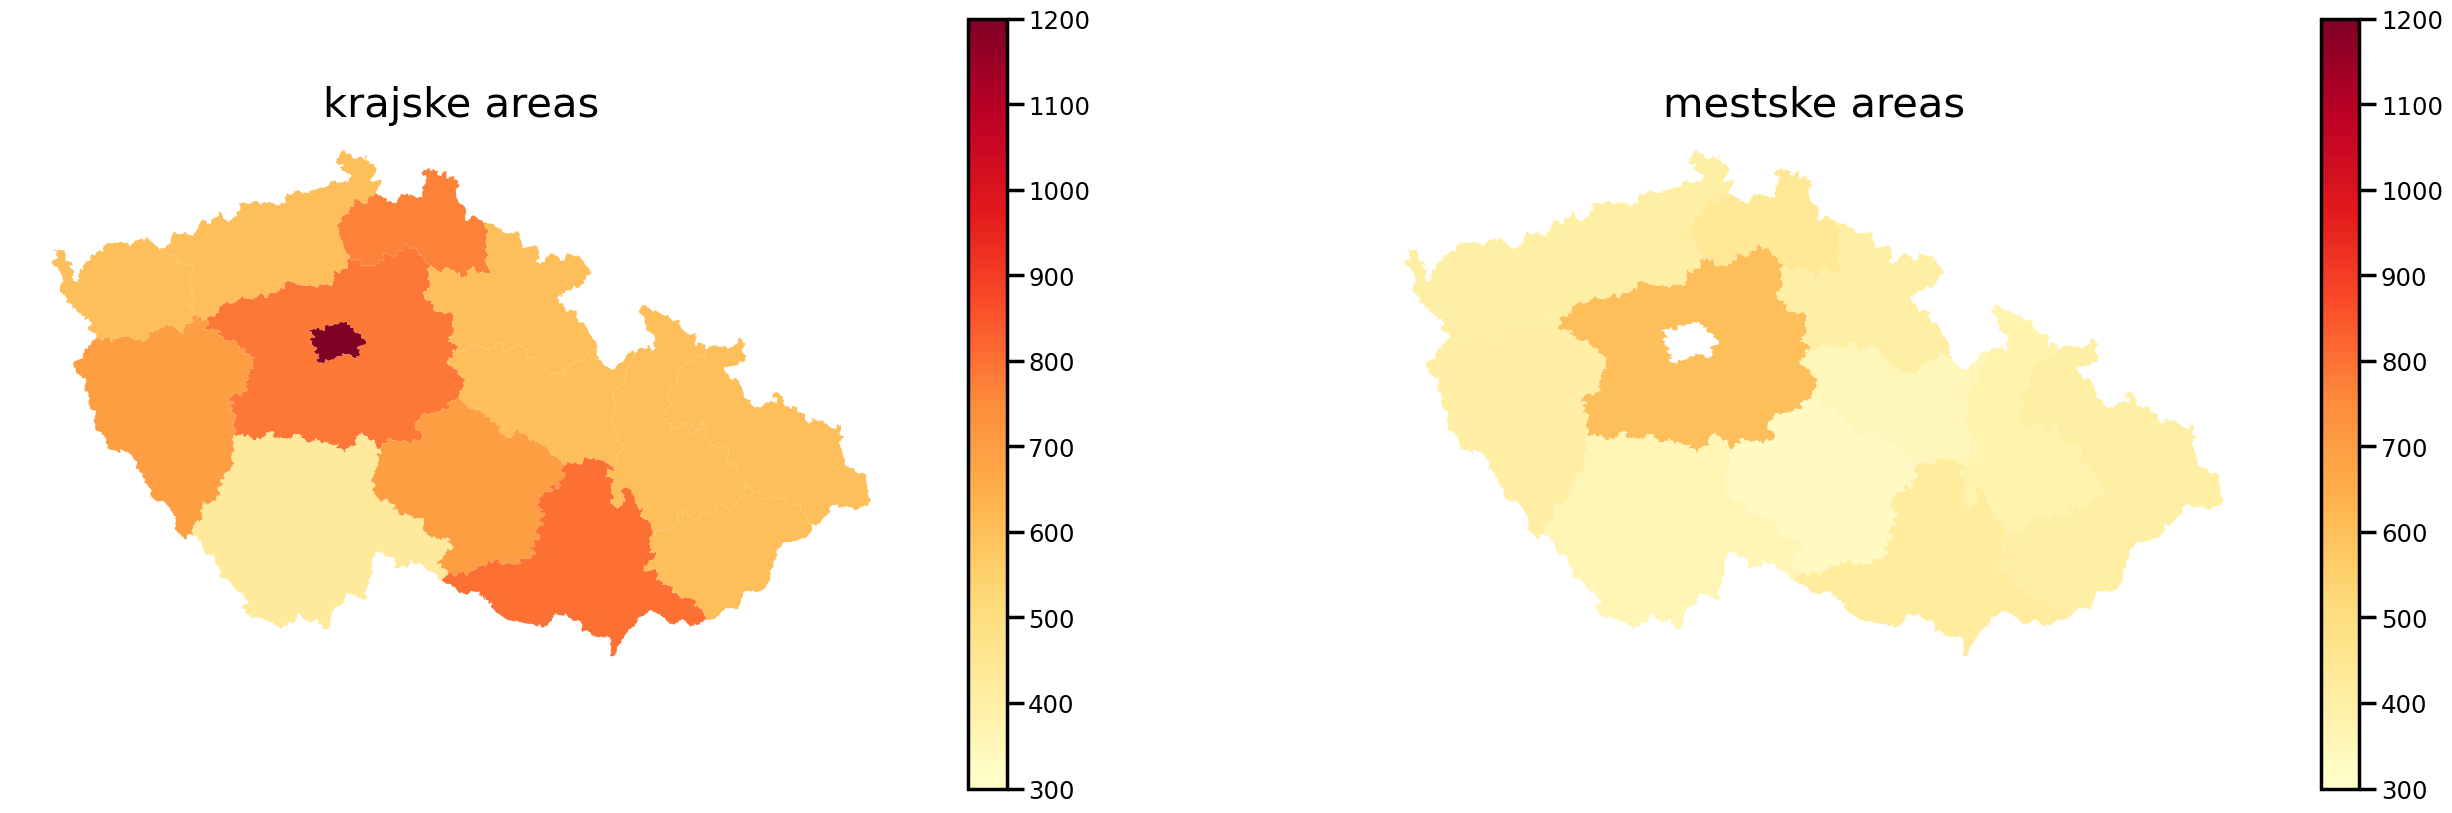

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))
  
kraj_m.plot(
    column="median_fee",
    ax=axes[0],
    figsize=(16, 10),
    cmap="YlOrRd",
    vmin=300,
    vmax=1200,
    legend=True)

axes[0].set_title("krajske areas",fontsize=30)
axes[0].set_axis_off()

kraj_v.plot(
    column="median_fee",
    ax=axes[1],

    figsize=(16, 10),
    vmin=300,
    vmax=1200,
    cmap="YlOrRd",
    legend=True)

axes[1].set_title("mestske areas",fontsize=30)
axes[1].set_axis_off()


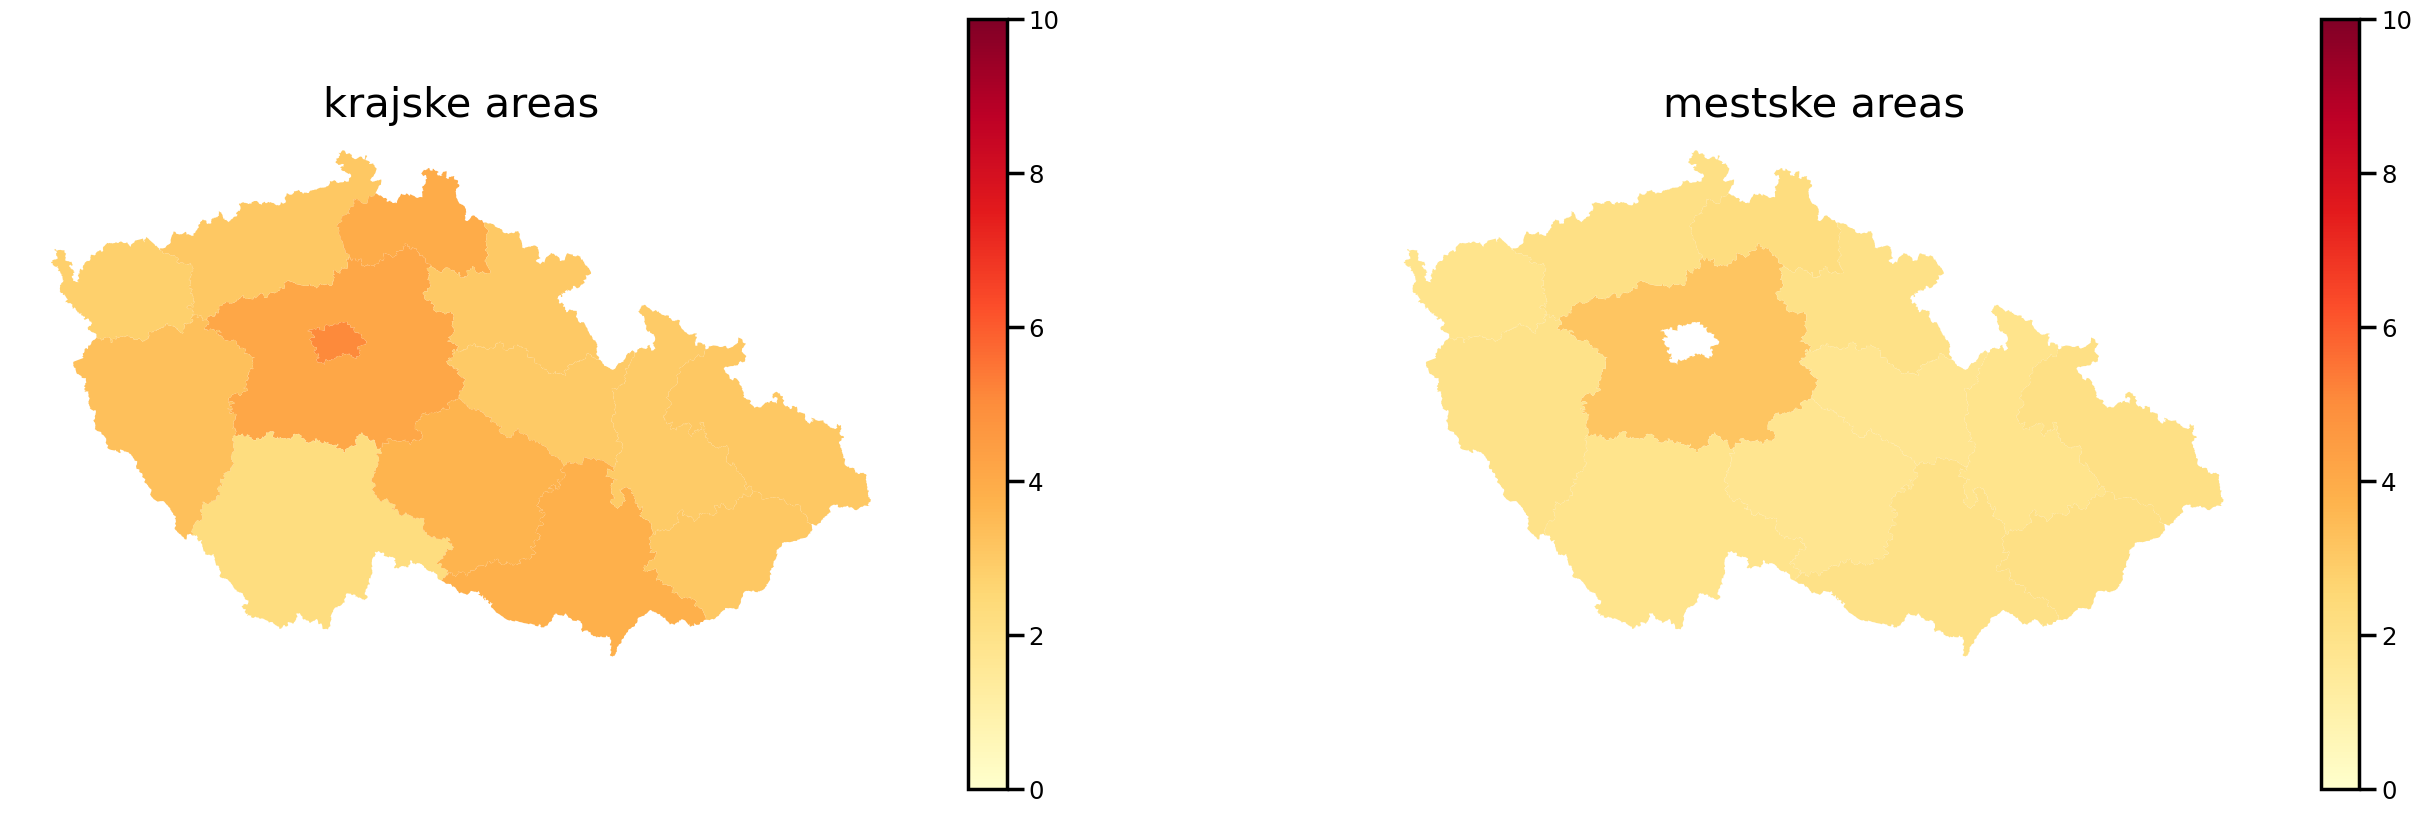

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))
  
kraj_m.plot(
    column="podil_median",
    ax=axes[0],
    figsize=(16, 10),
    cmap="YlOrRd",
    vmin=0,
    vmax=10,
    legend=True)

axes[0].set_title("krajske areas",fontsize=30)
axes[0].set_axis_off()

kraj_v.plot(
    column="podil_median",
    ax=axes[1],

    figsize=(16, 10),
    vmin=0,
    vmax=10,
    cmap="YlOrRd",
    legend=True)

axes[1].set_title("mestske areas",fontsize=30)
axes[1].set_axis_off()

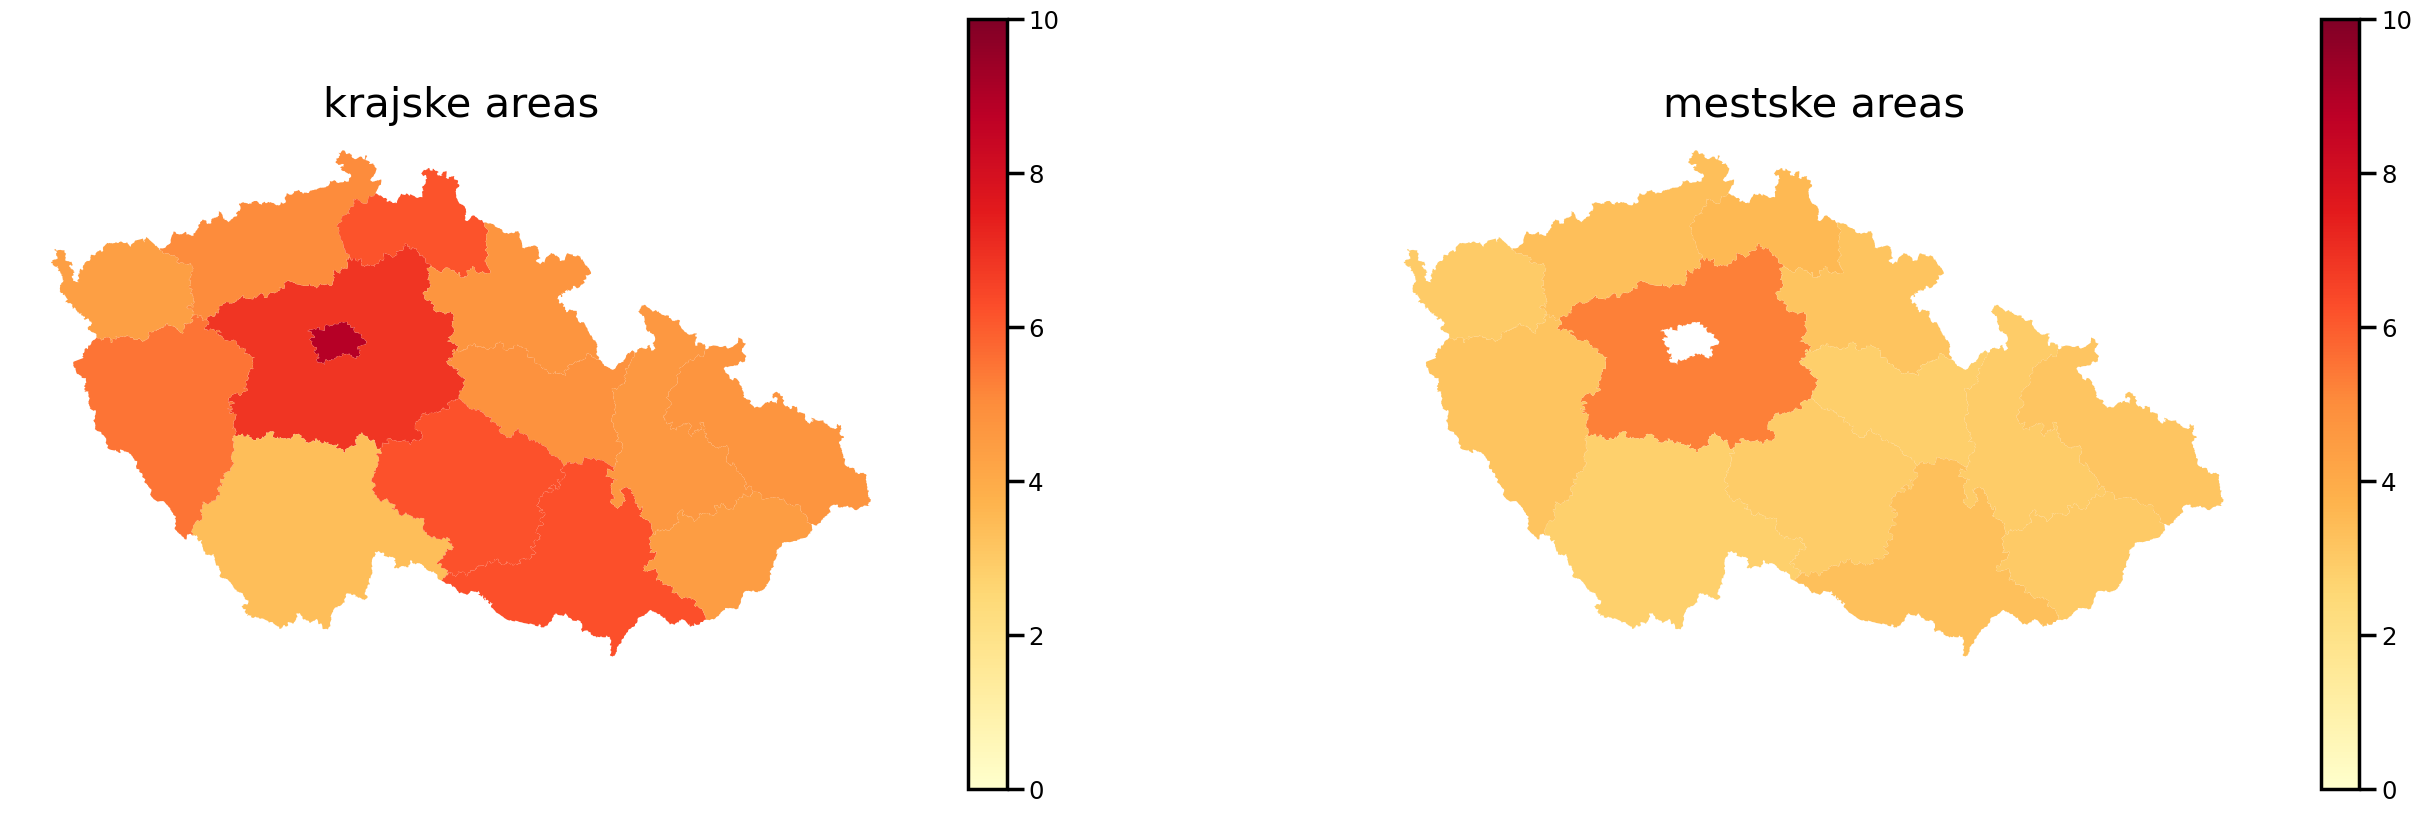

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))
  
kraj_m.plot(
    column="podil_decil",
    ax=axes[0],
    figsize=(16, 10),
    cmap="YlOrRd",
    vmin=0,
    vmax=10,
    legend=True)

axes[0].set_title("krajske areas",fontsize=30)
axes[0].set_axis_off()

kraj_v.plot(
    column="podil_decil",
    ax=axes[1],

    figsize=(16, 10),
    vmin=0,
    vmax=10,
    cmap="YlOrRd",
    legend=True)

axes[1].set_title("mestske areas",fontsize=30)
axes[1].set_axis_off()